# Forecast Model Evaluation

Notebook ini digunakan untuk membandingkan hasil prediksi model forecasting retail sales terhadap data aktual. Output yang dipakai berasal dari `ml/train_forecast_models.py`.

## 1. Import Library

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

ROOT_DIR = Path('..').resolve()
DATA_DIR = ROOT_DIR / 'data'

metrics_path = DATA_DIR / 'model_metrics.csv'
test_predictions_path = DATA_DIR / 'sales_forecast_test_predictions.csv'
future_forecast_path = DATA_DIR / 'sales_forecast_future.csv'

## 2. Load Model Outputs

In [2]:
metrics = pd.read_csv(metrics_path)
test_pred = pd.read_csv(test_predictions_path, parse_dates=['order_month'])
future_pred = pd.read_csv(future_forecast_path, parse_dates=['order_month'])

test_pred['error'] = test_pred['forecast_sales'] - test_pred['actual_sales']
test_pred['abs_error'] = test_pred['error'].abs()
test_pred['ape'] = test_pred['abs_error'] / test_pred['actual_sales'].replace(0, pd.NA) * 100

print('Metrics:', metrics.shape)
print('Test predictions:', test_pred.shape)
print('Future forecast:', future_pred.shape)

display(metrics.sort_values('rmse'))
display(test_pred.head())
display(future_pred.head())

Metrics: (3, 4)
Test predictions: (72, 8)
Future forecast: (72, 4)


,model_name,mae,rmse,mape
0,Linear Regression,"6,069.04","7,781.48",39.08
1,Random Forest,"6,386.37","8,092.21",36.12
2,XGBoost,"6,448.58","8,312.60",40.91


,region,order_month,actual_sales,model_name,forecast_sales,error,abs_error,ape
0,Central,2026-07-01,"9,598.04",Linear Regression,"12,751.99","3,153.95","3,153.95",32.86
1,Central,2026-08-01,"6,252.99",Linear Regression,"13,634.21","7,381.22","7,381.22",118.04
2,Central,2026-09-01,"17,343.00",Linear Regression,"15,664.53","-1,678.47","1,678.47",9.68
3,Central,2026-10-01,"12,152.73",Linear Regression,"16,315.01","4,162.28","4,162.28",34.25
4,Central,2026-11-01,"15,154.98",Linear Regression,"18,953.79","3,798.81","3,798.81",25.07


,region,order_month,forecast_sales,model_name
0,Central,2027-01-01,"6,290.00",Linear Regression
1,Central,2027-02-01,"8,438.75",Linear Regression
2,Central,2027-03-01,"10,075.52",Linear Regression
3,Central,2027-04-01,"9,850.40",Linear Regression
4,Central,2027-05-01,"11,205.81",Linear Regression


## 3. Model Metric Comparison

Semakin kecil nilai MAE, RMSE, dan MAPE, semakin baik performa model. RMSE lebih sensitif terhadap error besar, sedangkan MAPE lebih mudah dibaca sebagai persentase.

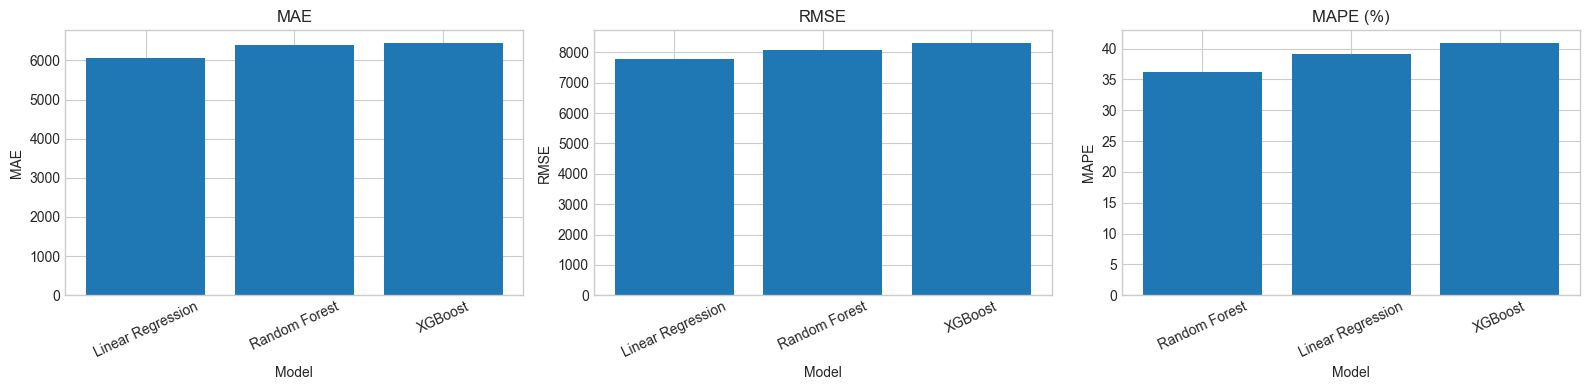

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ['mae', 'rmse', 'mape'],
    ['MAE', 'RMSE', 'MAPE (%)']
):
    sorted_metrics = metrics.sort_values(metric)
    ax.bar(sorted_metrics['model_name'], sorted_metrics[metric])
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 4. Actual vs Prediction by Region

Grafik ini membandingkan data aktual dengan prediksi setiap model pada periode test.

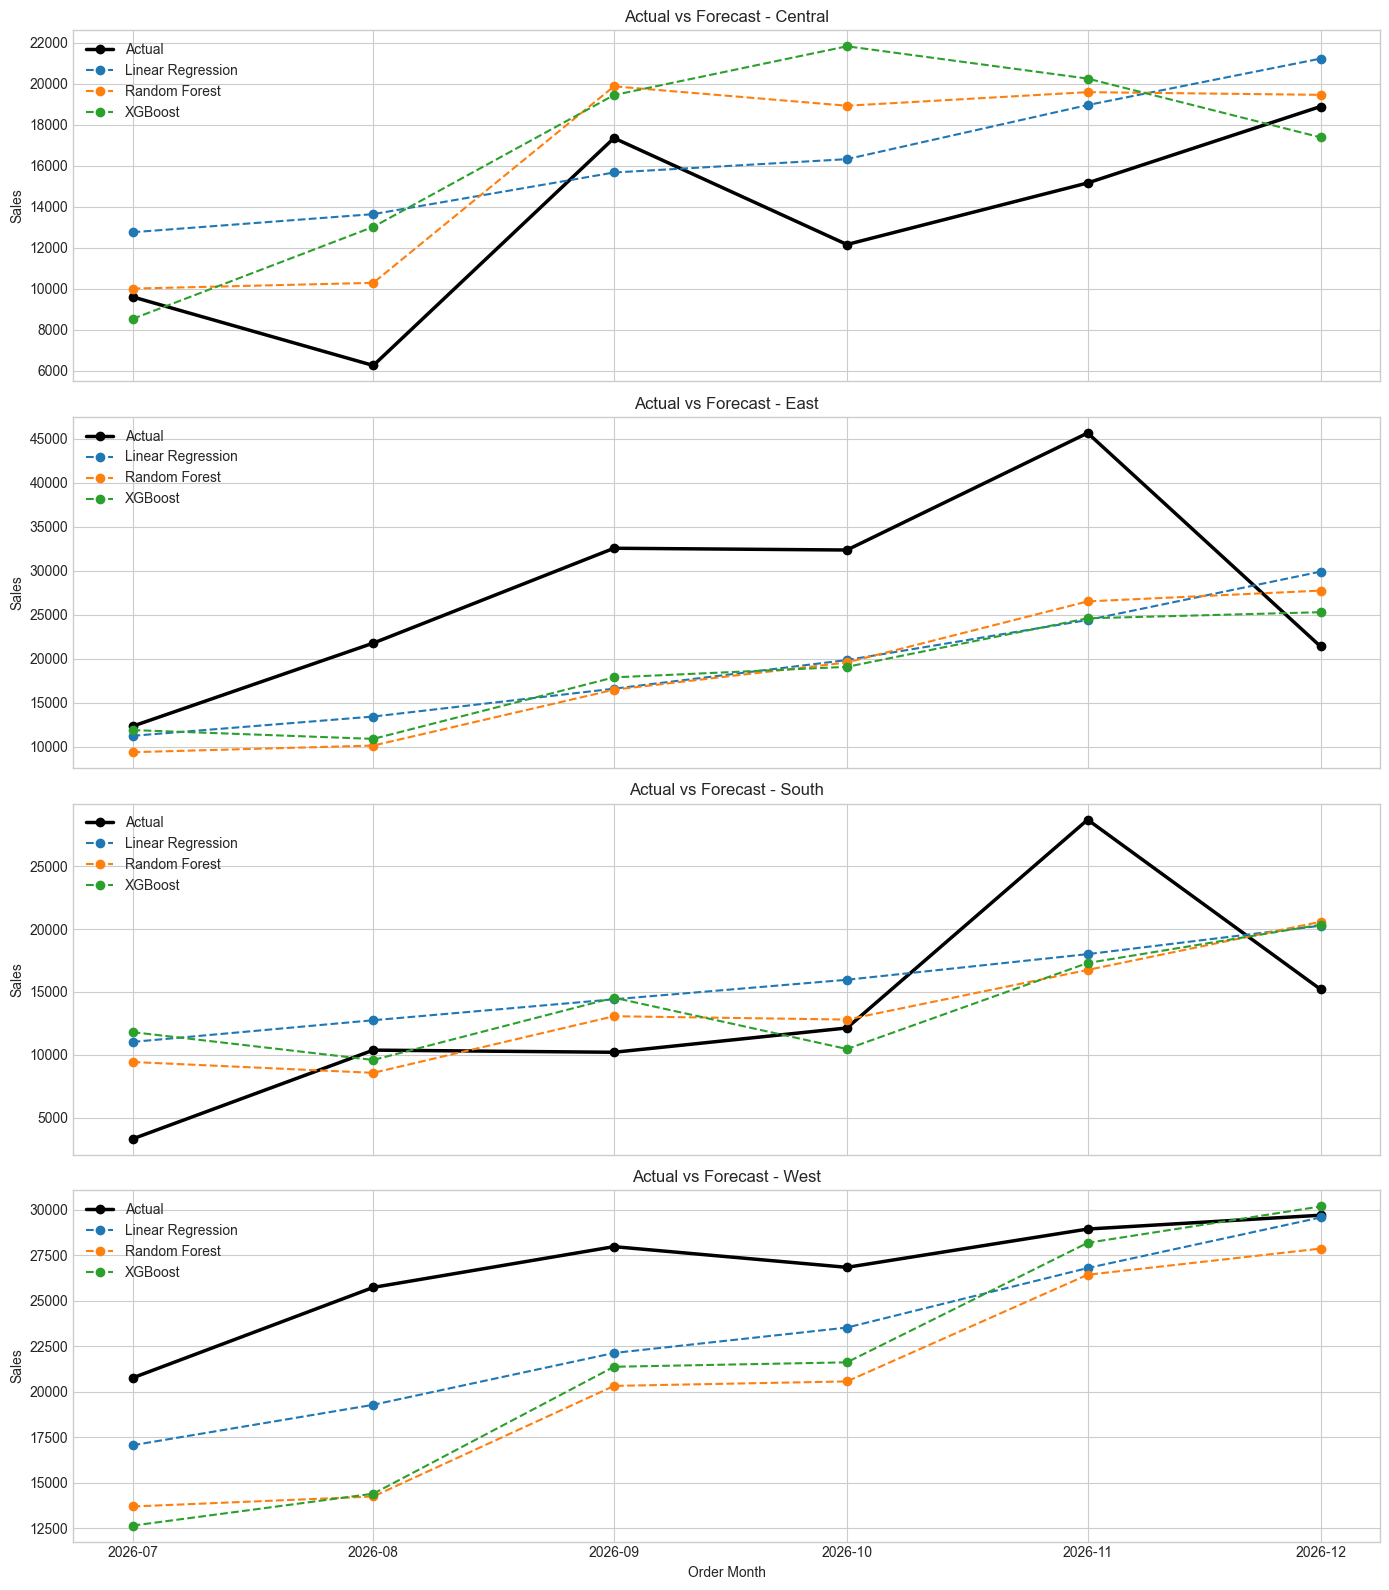

In [4]:
regions = sorted(test_pred['region'].unique())
models = metrics['model_name'].tolist()

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 4 * len(regions)), sharex=True)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    region_df = test_pred[test_pred['region'] == region].sort_values('order_month')
    actual = region_df.drop_duplicates('order_month')

    ax.plot(
        actual['order_month'],
        actual['actual_sales'],
        marker='o',
        linewidth=2.5,
        label='Actual',
        color='black'
    )

    for model_name in models:
        model_df = region_df[region_df['model_name'] == model_name]
        ax.plot(
            model_df['order_month'],
            model_df['forecast_sales'],
            marker='o',
            linestyle='--',
            label=model_name
        )

    ax.set_title(f'Actual vs Forecast - {region}')
    ax.set_ylabel('Sales')
    ax.legend(loc='upper left')

plt.xlabel('Order Month')
plt.tight_layout()
plt.show()

## 5. Error Distribution

Boxplot ini membantu melihat model mana yang error-nya lebih stabil. Semakin kecil dan rapat distribusi error, semakin baik.

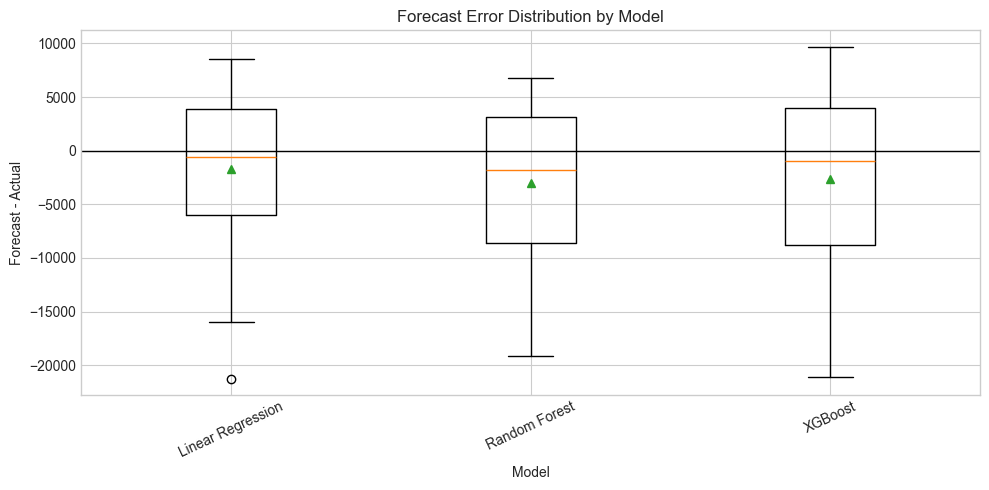

In [5]:
error_by_model = [
    test_pred.loc[test_pred['model_name'] == model_name, 'error']
    for model_name in models
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(error_by_model, tick_labels=models, showmeans=True)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Forecast Error Distribution by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Forecast - Actual')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Average Error by Region

,model_name,region,mae,mape,bias
3,Linear Regression,West,"3,592.87",13.98,"-3,592.87"
0,Linear Regression,Central,"3,751.85",38.71,"3,192.36"
2,Linear Regression,South,"5,655.18",66.74,"2,087.86"
1,Linear Regression,East,"11,276.27",36.87,"-8,440.00"
4,Random Forest,Central,"3,120.57",28.52,"3,120.57"
6,Random Forest,South,"4,802.64",52.27,212.75
7,Random Forest,West,"6,133.03",24.02,"-6,133.03"
5,Random Forest,East,"11,489.23",39.66,"-9,372.07"
8,XGBoost,Central,"4,365.48",42.08,"3,506.23"
10,XGBoost,South,"5,309.83",65.83,687.57


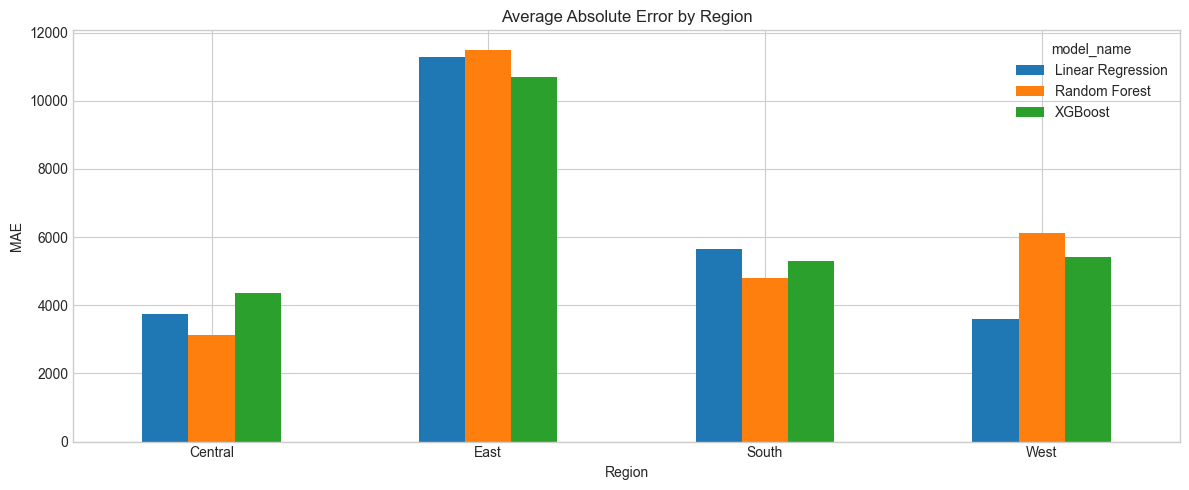

In [6]:
region_error = (
    test_pred
    .groupby(['model_name', 'region'], as_index=False)
    .agg(
        mae=('abs_error', 'mean'),
        mape=('ape', 'mean'),
        bias=('error', 'mean')
    )
)

display(region_error.sort_values(['model_name', 'mae']))

pivot_mae = region_error.pivot(index='region', columns='model_name', values='mae')
pivot_mae.plot(kind='bar', figsize=(12, 5))
plt.title('Average Absolute Error by Region')
plt.xlabel('Region')
plt.ylabel('MAE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Future Forecast by Region

Grafik ini menampilkan prediksi 6 bulan ke depan dari setiap model.

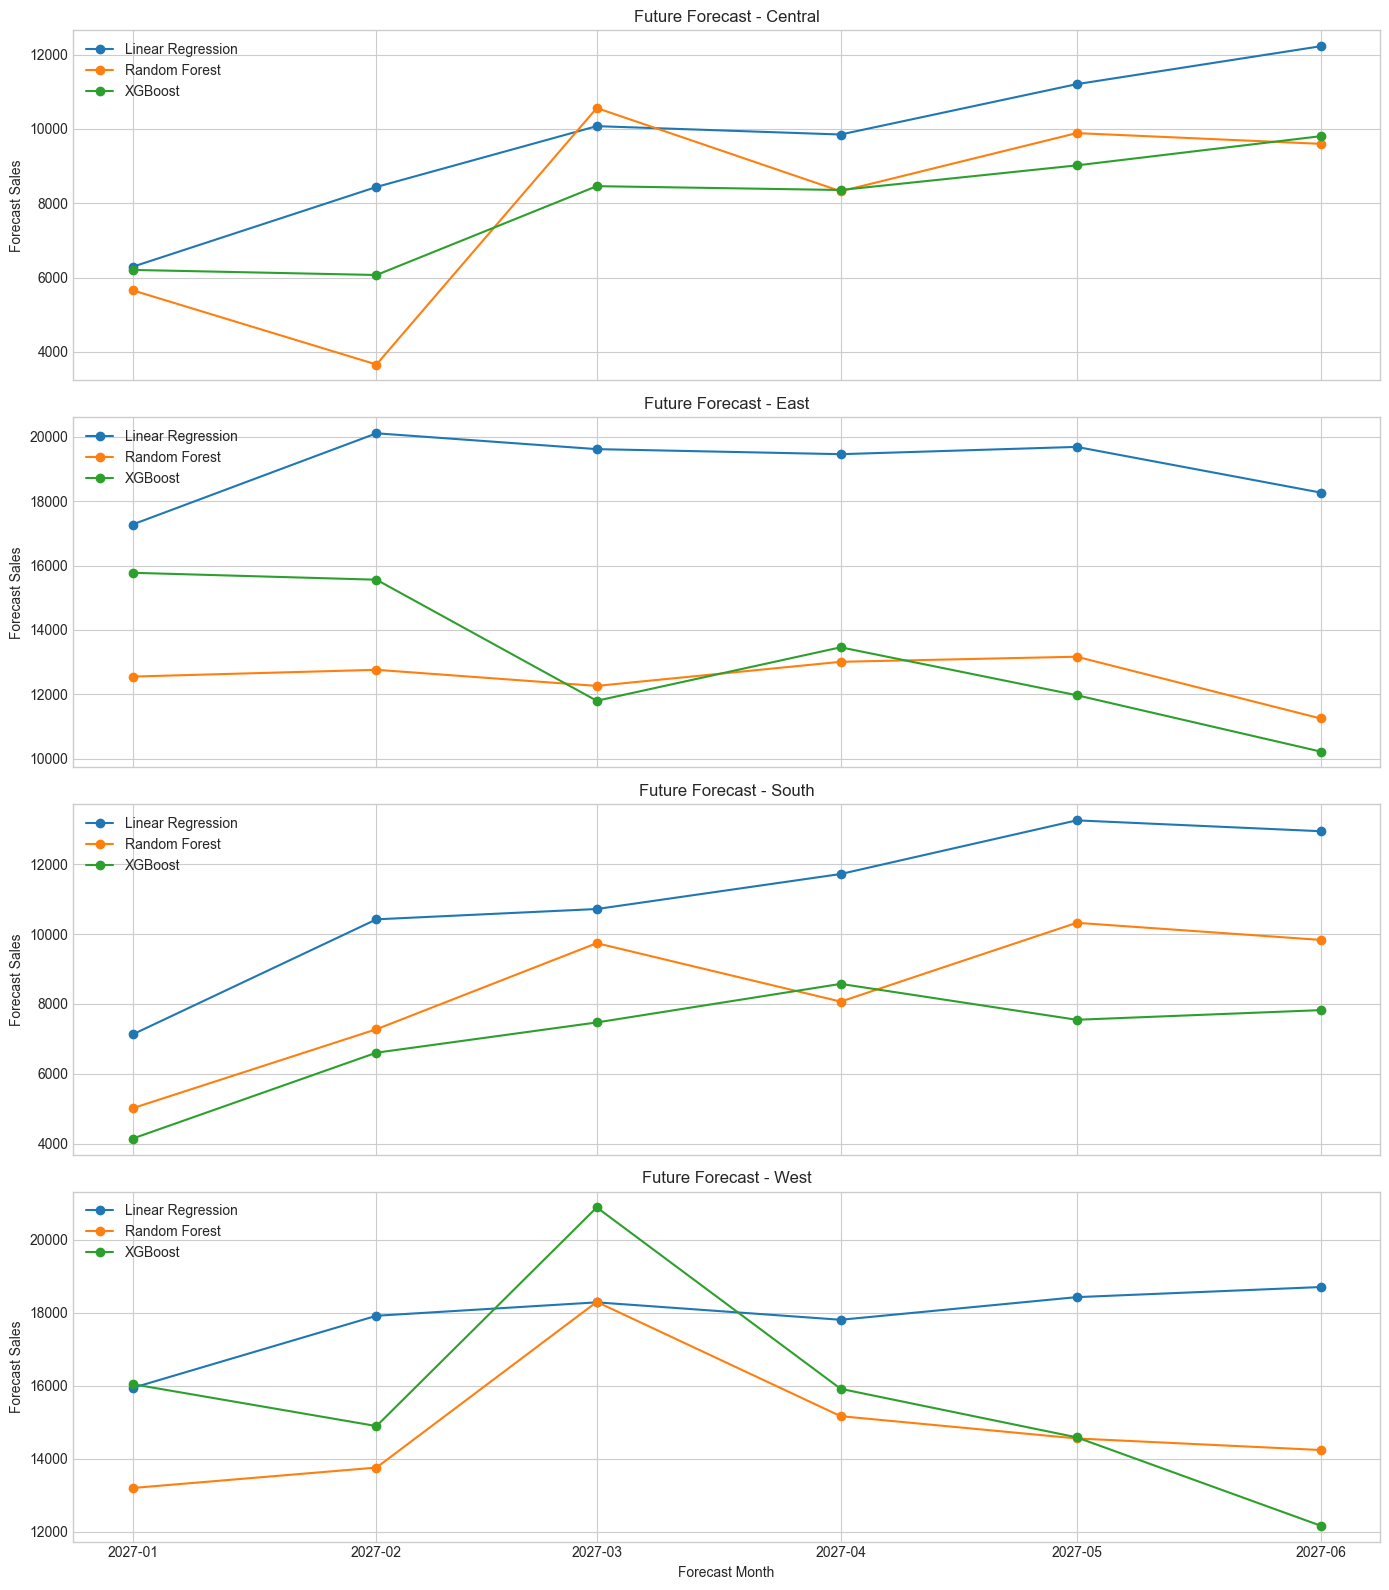

In [7]:
fig, axes = plt.subplots(len(regions), 1, figsize=(14, 4 * len(regions)), sharex=True)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    region_df = future_pred[future_pred['region'] == region].sort_values('order_month')

    for model_name in models:
        model_df = region_df[region_df['model_name'] == model_name]
        ax.plot(
            model_df['order_month'],
            model_df['forecast_sales'],
            marker='o',
            label=model_name
        )

    ax.set_title(f'Future Forecast - {region}')
    ax.set_ylabel('Forecast Sales')
    ax.legend(loc='upper left')

plt.xlabel('Forecast Month')
plt.tight_layout()
plt.show()

## 8. Interpretation

Dari hasil awal, performa model masih cukup kasar karena data training hanya berisi agregasi bulanan per region. Linear Regression menjadi baseline yang kuat untuk RMSE, sedangkan Random Forest bisa lebih baik dari sisi MAPE. XGBoost belum otomatis lebih baik karena jumlah data relatif kecil.

Untuk iterasi berikutnya, pertimbangkan menambah data historis, menambah fitur kategori, membuat forecast per category, atau menggunakan model time-series khusus sebagai pembanding.